# 부산광역시 쓰레기 배출량 예측 pt.7

### : 가장 높은 R2를 위한 종속변수의 조합 찾기 +  예측 및 취약지역 선정까지

<br>

## 00. 기본 설정 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact

# 경고 메시지는 출력 X
import warnings
warnings.filterwarnings("ignore")

In [2]:
# 한글 font 설정

import platform
import matplotlib.font_manager as fm

#matplotlib 패키지 한글 깨짐 처리
#------------------------------------------------------------------------------------
# 운영체제별 한글 폰트 설정

if platform.system() == 'Darwin':           # Mac 환경 폰트 설정
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':        # Windows 환경 폰트 설정
    plt.rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False #한글 폰트 사용시 마이너스 폰트 깨짐 해결

In [3]:
# 글씨 선명하게 출력하는 설정

from IPython.display import set_matplotlib_formats
set_matplotlib_formats("retina")

<Axes: title={'center': '한글타이틀'}>

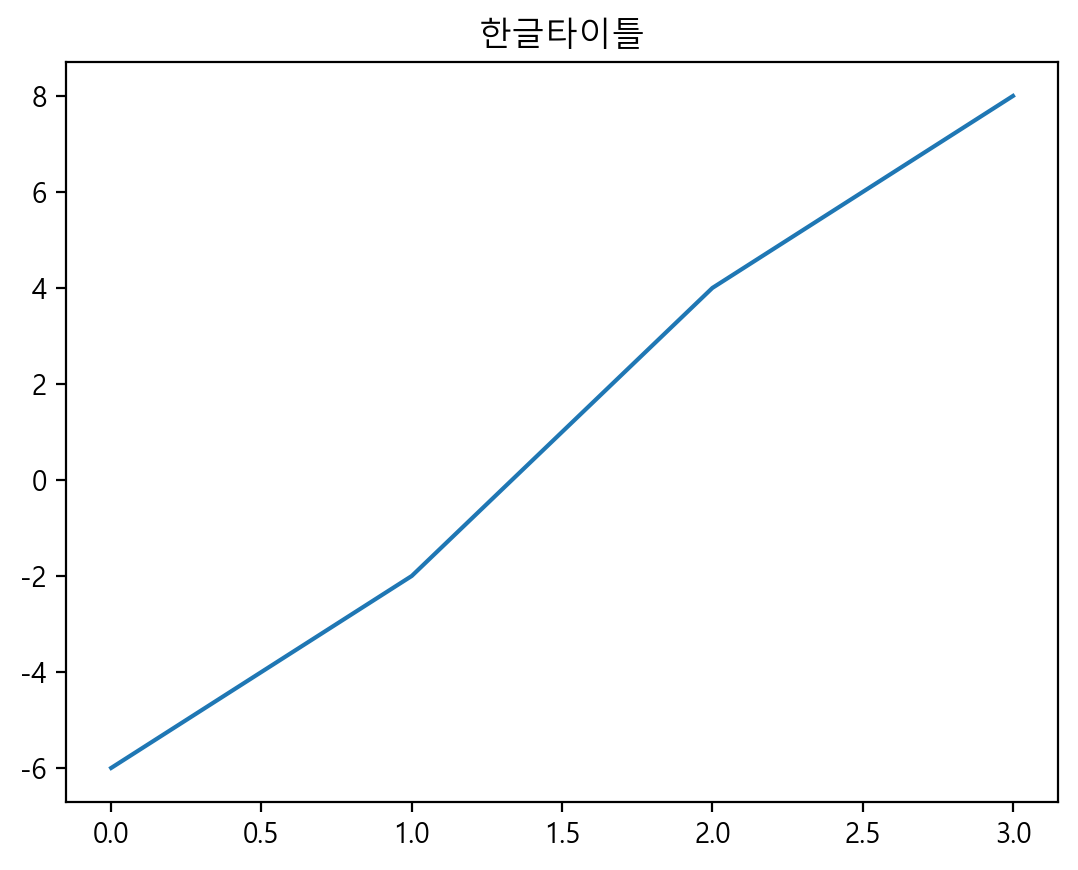

In [4]:
# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-6, -2, 4, 8]).plot(title="한글타이틀")

<br><br>

---
## 01. 데이터 불러오기

In [5]:
df = pd.read_csv("data/최종_모델학습용.csv", encoding="cp949")
print(f"데이터프레임 shape: {df.shape}")
df.head(3)

데이터프레임 shape: (590, 25)


,행정구역,혼합배출_후_재활용량,시도,시군구,주민등록세대수,총인구수,단독주택비율,아파트비율,연립주택비율,다세대주택비율,...,1인가구_비율,2인가구_비율,3인가구_비율,4인가구_비율,5인이상가구_비율,연도_2019,연도_2020,연도_2021,연도_2022,연도_2023
0,강원_고성군,2863.8,강원,고성군,15291,27274,0.6845,0.2642,0.0116,0.0115,...,0.386303,0.365099,0.144122,0.074742,0.029734,0,0,0,1,0
1,강원_고성군,2467.3,강원,고성군,15431,27305,0.6840,0.2650,0.0116,0.0114,...,0.415669,0.353801,0.134385,0.071040,0.025105,0,0,0,0,1
2,강원_동해시,4818.0,강원,동해시,41141,90522,0.2689,0.6416,0.0426,0.0296,...,0.291131,0.333738,0.198045,0.133457,0.043630,1,0,0,0,0


<br><br>

---
## 02. 분석 목표 정의

<br>

> **종량제 방식으로 혼합 배출되었지만, '재활용' 처리된 양 예측하기**

- 혼합배출 → 분류작업 → 재활용 처리된 자원의 양
- **이중처리로 인한 추가 비용**이 발생한 자원량을 예측하는 것  

<br>

- 종속변수를 **`종량제방식 등 혼합배출에서 재활용 처리된 값`** 으로 설정해서 모델링 및 튜닝을 해보고자 함

<br><br>

---
## 03. RandomForest 모델 test
- 로그 변환한 y값(종속변수) `log_혼합배출_후_재활용량` 쓰고
- 독립변수는 로그변환하지 않은 값을 사용할 거임

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from itertools import combinations

<br>

### 03-1. 임의로 선택한 변수들로 조합해서 가장 높은 R2값 만들기

In [7]:
# 선택한 변수 중 조합을 만들어 테스트하는 함수 정의
def explore_feature_combinations(
    data: pd.DataFrame,           # 사용할 데이터프레임
    selected_core_features: list, # 조합을 탐색할 독립 변수(X) 리스트
    max_features,
    min_features,                 # 조합할 최소 피처 개수
    n_estimators: int = 250,      # Random Forest 모델의 트리 개수
    verbose: bool = True          # 진행 상황을 출력할지 여부 (True면 출력)
) -> pd.DataFrame:                # return: 각 피처 조합에 대한 R2-MSE-feature importance

    X_all = data[selected_core_features]    # 선택된 핵심 피처만으로 X_all 구성
    y_all = data['log_혼합배출_후_재활용량']   # 타겟 변수 Y

    max_features_to_explore = len(selected_core_features) # 핵심 피처 리스트의 최대 길이
    all_results = []                                      # 모든 조합의 결과를 저장할 리스트

    if verbose:
        print(f"--- {max_features_to_explore}개의 피처 내 조합 Random Forest 성능 탐색 시작 ---")

    # min_features부터 max_features_to_explore까지 피처 개수를 늘려가며 반복
    for k in range(min_features, max_features + 1):
        if verbose:
            print(f"\n[--- {k}개 피처 조합 탐색 시작 ---]")

        # k개의 피처를 선택하는 모든 가능한 조합 생성
        feature_combinations = list(combinations(selected_core_features, k))

        # 각 조합에 대해 모델 훈련 및 평가
        for combo_idx, selected_features_tuple in enumerate(feature_combinations):
            selected_features = list(selected_features_tuple)

            # 선택된 피처들로 X_sub 데이터프레임 생성
            X_sub = X_all[selected_features]

            # 데이터 학습/테스트 세트로 분할
            X_train, X_test, y_train, y_test = train_test_split(X_sub, y_all, test_size=0.2, random_state=42)
            
            # Random Forest 모델 훈련
            model = RandomForestRegressor(n_estimators=n_estimators, random_state=42)
            model.fit(X_train, y_train)

            # 예측 및 성능 평가
            y_pred = model.predict(X_test)
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)

            # 결과 저장
            all_results.append({
                'num_features': k,                                # 피처 개수
                'selected_features': selected_features,           # 선택된 피처 리스트
                'R2': r2,                                         # R2 점수
                'MSE': mse,                                       # MSE 점수
                'feature_importances': model.feature_importances_ # 해당 모델의 피처 중요도
            })

            # 진행 상황 출력 (100개 조합마다 || 마지막 조합에)
            if verbose and ((combo_idx + 1) % 100 == 0 or combo_idx == len(feature_combinations) - 1):
                print(f"  > 조합 {combo_idx+1}/{len(feature_combinations)} 완료 - R2: {r2:.4f}, MSE: {mse:.4f}")

    results_df = pd.DataFrame(all_results)
    # R2 기준으로 결과를 내림차순 정렬
    results_df_sorted = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

    if verbose:
        print("\n--- 탐색 완료 ---")
        print("\n--- 각 피처 개수별 최고 R2 ---")
        # 각 피처 개수(num_features)별로 R2가 가장 높은 행만 추출하여 출력
        print(results_df.loc[results_df.groupby('num_features')['R2'].idxmax()])
    
    return results_df_sorted

In [8]:
def plot_model_performance_and_importance(results_df: pd.DataFrame):
    if results_df.empty:
        print("시각화를 할 수 없음. 데이터프레임이 없다..!")
        return

    # num_feature별로 가장 높은 R2값 정렬
    plot_data = results_df.loc[results_df.groupby('num_features')['R2'].idxmax()].reset_index(drop=True)

    # feature의 수에 상관없이 R2가 가장 높은 건 데이터프레임의 0번째 행에 있음
    best_model_row = results_df.iloc[0]
    best_r2_score = best_model_row['R2']
    best_features_combo = best_model_row['selected_features']
    best_importances = best_model_row['feature_importances']
    best_num_features = best_model_row['num_features']

    # 베스트 모델의 feature importance 데이터프레임 만들기
    best_importance_df = pd.DataFrame({
        'feature': best_features_combo,
        'importance': best_importances
    }).sort_values(by='importance', ascending=False)

    # 그래프의 크기 설정
    height_ratio_plot1 = 1.0
    height_ratio_plot2 = max(0.5, len(best_features_combo) * 0.1)

    base_figure_height = 8 
    total_figure_height_ratio = height_ratio_plot1 + height_ratio_plot2
    calculated_height = base_figure_height * (total_figure_height_ratio / 1.5)

    fig, axes = plt.subplots(2, 1, figsize=(10, calculated_height),
                             gridspec_kw={'height_ratios': [height_ratio_plot1, height_ratio_plot2]})
    fig.suptitle('모델 성능 및 피처 중요도 분석', fontsize=16, y=1.02)

    # --- Plot 1: feature의 개수에 따른 R2와 MSE ---
    ax1 = axes[0]
    ax1_2 = ax1.twinx()

    sns.lineplot(x='num_features', y='R2', data=plot_data, marker='o', color='green', ax=ax1)
    sns.lineplot(x='num_features', y='MSE', data=plot_data, marker='s', color='orange', ax=ax1_2)

    ax1.set_xlabel("Number of Features")
    ax1.set_ylabel("R2 Score", color='green')
    ax1_2.set_ylabel("Mean Squared Error (MSE)", color='orange')
    ax1.tick_params(axis='y', labelcolor='green')
    ax1_2.tick_params(axis='y', labelcolor='orange')
    ax1.set_title("R2 Score and MSE by Number of Features")
    ax1.grid(True, linestyle='--', alpha=0.3)

    lines = [
        plt.Line2D([0], [0], color='green', marker='o', label='R2 Score'),
        plt.Line2D([0], [0], color='orange', marker='s', label='MSE')
    ]
    ax1.legend(handles=lines, loc='upper right')

    # --- Plot 2: 베스트 모델의 Feature Importance ---
    ax3 = axes[1]
    sns.barplot(data=best_importance_df, x='importance', y='feature', palette='viridis', ax=ax3)
    ax3.set_title(f'Feature Importance for Best Model (Top {best_num_features} Features, R²={best_r2_score:.4f})')
    ax3.set_xlabel('Importance')
    ax3.set_ylabel('Feature')

    plt.tight_layout(rect=[0, 0.03, 1, 0.98])

<br>

---
### test 1)

In [132]:
# feature 리스트 정의
my_selected_features_set1 = [
    '총인구수', '주민등록세대수', '아파트비율', '1인가구_비율', '순이동', '총전입'
]

# 함수 호출 및 결과 저장
results_set1 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set1,
    min_features=3,
    max_features=6
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set1.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 6개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 20/20 완료 - R2: 0.2591, MSE: 1.0605

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 15/15 완료 - R2: 0.3192, MSE: 0.9745

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 6/6 완료 - R2: 0.4228, MSE: 0.8262

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.4398, MSE: 0.8019

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                          selected_features        R2  \
0              3                     [총인구수, 주민등록세대수, 아파트비율]  0.608490   
22             4                [총인구수, 주민등록세대수, 아파트비율, 총전입]  0.551231   
37             5           [총인구수, 주민등록세대수, 아파트비율, 순이동, 총전입]  0.490907   
41             6  [총인구수, 주민등록세대수, 아파트비율, 1인가구_비율, 순이동, 총전입]  0.439774   

         MSE                                feature_importances  
0   0.560416  [0.43697832788602153, 0.30774511111613756, 0.2...  
22  0.642378  [0.3909239586672116, 0.2660763057127617, 0.208...  
37  0.728726  [0.35187249185172165, 0.2384891176695895, 0.17...  
41  0.801920  [0.322

,num_features,selected_features,R2,MSE,feature_importances
0,3,"[총인구수, 주민등록세대수, 아파트비율]",0.608490,0.560416,"[0.43697832788602153, 0.30774511111613756, 0.2..."
1,4,"[총인구수, 주민등록세대수, 아파트비율, 총전입]",0.551231,0.642378,"[0.3909239586672116, 0.2660763057127617, 0.208..."
2,4,"[총인구수, 주민등록세대수, 아파트비율, 순이동]",0.547411,0.647846,"[0.38476564377544353, 0.26368668962748965, 0.2..."


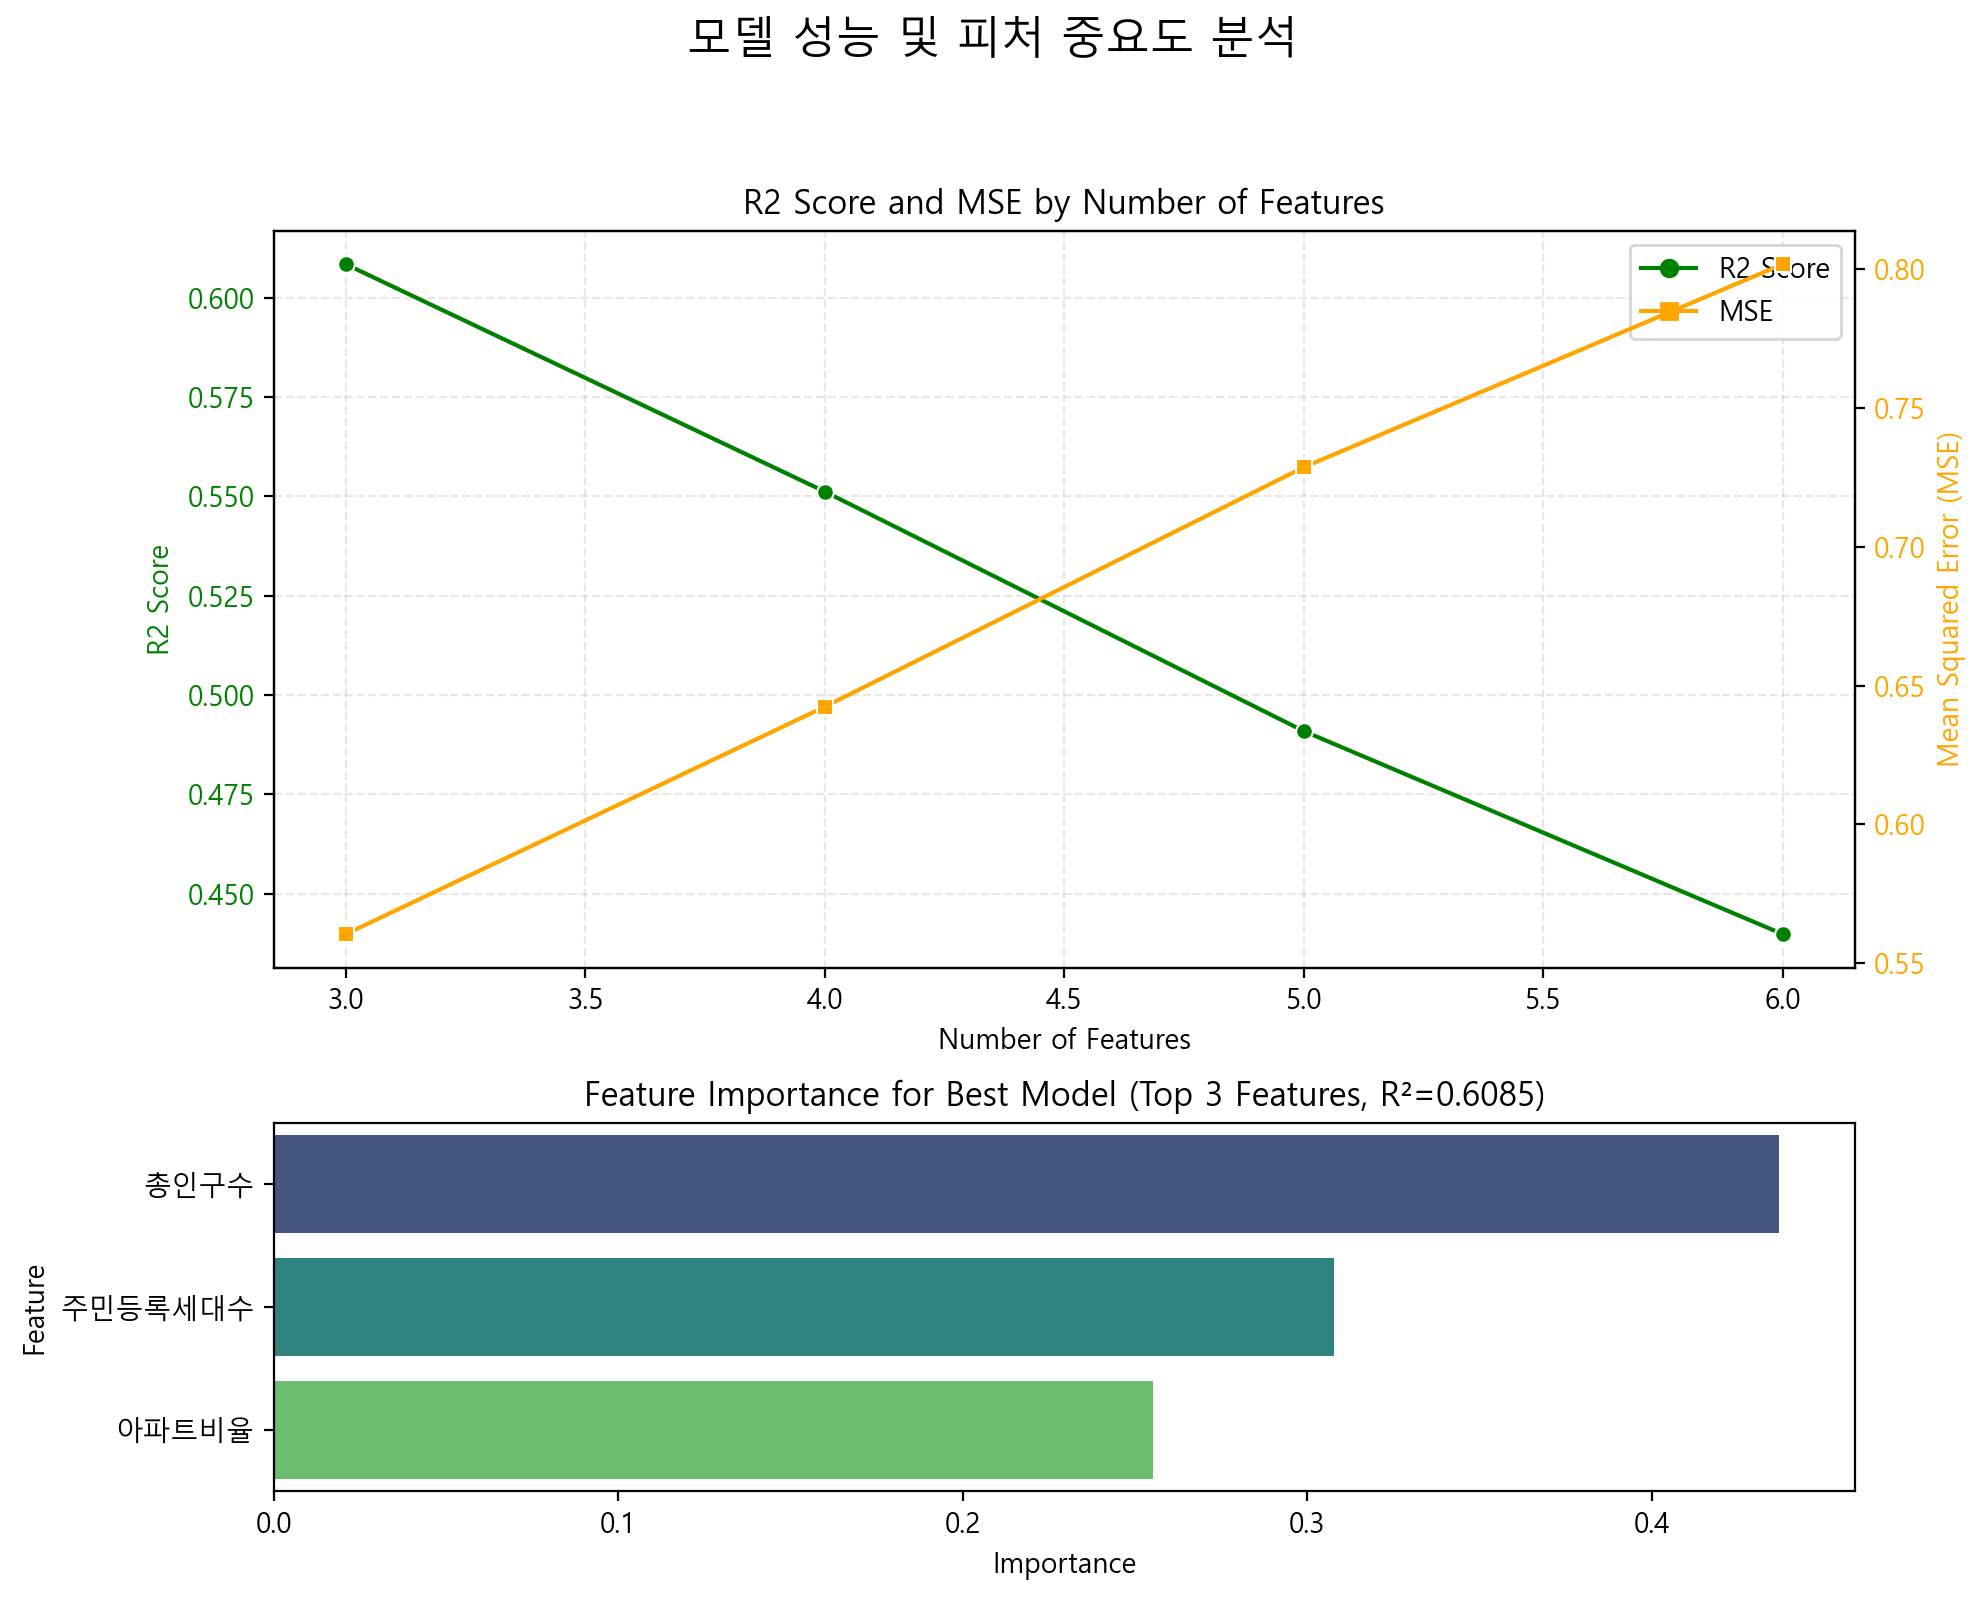

In [133]:
plot_model_performance_and_importance(results_set1)

<br>

---
### test 2) 단순 조합

In [158]:
my_selected_features_set2 = [
    '총인구수', '아파트비율', '단독주택비율', '5인이상가구_비율', '1인가구_비율'
]

# 함수 호출 및 결과 저장
results_set2 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set2,
    min_features=3,
    max_features=5
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set2.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 5개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.3390, MSE: 0.9462

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.4157, MSE: 0.8364

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.5488, MSE: 0.6458

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                          selected_features        R2  \
0              3                      [총인구수, 아파트비율, 단독주택비율]  0.599577   
11             4             [총인구수, 아파트비율, 단독주택비율, 1인가구_비율]  0.592133   
15             5  [총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율, 1인가구_비율]  0.548843   

         MSE                                feature_importances  
0   0.573174  [0.5270698603132992, 0.21322272819123086, 0.25...  
11  0.583830  [0.4805132841021176, 0.15937866638616693, 0.19...  
15  0.645796  [0.4539531252810194, 0.13378233903758002, 0.17...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,3,"[총인구수, 아파트비율, 단독주택비율]",0.599577,0.573174,"[0.5270698603132992, 0.21322272819123086, 0.25..."
1,4,"[총인구수, 아파트비율, 단독주택비율, 1인가구_비율]",0.592133,0.583830,"[0.4805132841021176, 0.15937866638616693, 0.19..."
2,4,"[총인구수, 아파트비율, 단독주택비율, 5인이상가구_비율]",0.588589,0.588902,"[0.4795500852774071, 0.1619425964384621, 0.201..."


- 지금까지는 **`[총인구수, 주민등록세대수, 아파트비율] (R2: 0.608490)`** 가 최고 조합

<br>

---
### test 3) 인구 + 주거유형

In [135]:
my_selected_features_set3 = [
    '총전입', '아파트비율', '다세대주택비율', '1인가구_비율', '총인구수'
]

# 함수 호출 및 결과 저장
results_set3 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set3,
    min_features=3,
    max_features=4
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set3.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 5개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 10/10 완료 - R2: 0.5041, MSE: 0.7098

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 5/5 완료 - R2: 0.5634, MSE: 0.6249

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                selected_features        R2       MSE  \
7              3           [아파트비율, 다세대주택비율, 총인구수]  0.572253  0.612287   
14             4  [아파트비율, 다세대주택비율, 1인가구_비율, 총인구수]  0.563406  0.624950   

                                  feature_importances  
7   [0.23343962024864714, 0.18322362747247062, 0.5...  
14  [0.17187409117840016, 0.13279818450121858, 0.1...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,3,"[아파트비율, 다세대주택비율, 총인구수]",0.572253,0.612287,"[0.23343962024864714, 0.18322362747247062, 0.5..."
1,4,"[아파트비율, 다세대주택비율, 1인가구_비율, 총인구수]",0.563406,0.624950,"[0.17187409117840016, 0.13279818450121858, 0.1..."
2,4,"[총전입, 아파트비율, 다세대주택비율, 총인구수]",0.520138,0.686886,"[0.14364003589650773, 0.1841532471747959, 0.15..."


<br>

---
### 지금까지 한 test 1 ~ test 3 정리)
| 조합                                                  | 최고 R2     | 특징                       |
| --------------------------------------------------- | --------- | --------------------------- |
| `[총인구수, 주민등록세대수, 아파트비율]` | **0.608** | 가장 높은 R2, 주민등록세대수랑 총인구수랑 비슷함 |
| `[아파트비율, 다세대주택비율, 총인구수]` | **0.572** | 인구 + 주거 |

> **`총인구수`가 포함될 때 R2가 확실히 올라감**

> `1인가구_비율`은 단독 기여도 낮음

> `아파트비율`은 여러 개의 조합에 포함되어 있음

<br>

---
### test 5)

In [139]:
my_selected_features_set5 = [
    '총인구수', '아파트비율', '다세대주택비율', '단독주택비율',
    '4인가구_비율', '2인가구_비율', '총전입', '순이동'
]

# 함수 호출 및 결과 저장
results_set5 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set5,
    min_features=3,
    max_features=8
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set5.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 8개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.3522, MSE: 0.9273

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 70/70 완료 - R2: 0.3916, MSE: 0.8709

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.4870, MSE: 0.7344

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 28/28 완료 - R2: 0.5509, MSE: 0.6428

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 8/8 완료 - R2: 0.5631, MSE: 0.6254

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.6368, MSE: 0.5199

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                                  selected_features  \
12              3                            [총인구수, 단독주택비율, 2인가구_비율]   
71              4                   [총인구수, 다세대주택비율, 단독주택비율, 4인가구_비율]   
146             5          [총인구수, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비율]   
182             6   [총인구수, 아파트비율, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비율]   
211             7  [총인구수, 아파트비율, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비...   
218             8  [총인구수, 아파트비율, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비...   

         

,num_features,selected_features,R2,MSE,feature_importances
0,4,"[총인구수, 다세대주택비율, 단독주택비율, 4인가구_비율]",0.706714,0.419816,"[0.4973305083275137, 0.15067684234953915, 0.22..."
1,5,"[총인구수, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비율]",0.692843,0.439672,"[0.46445318960667, 0.12682073200836108, 0.1826..."
2,6,"[총인구수, 아파트비율, 다세대주택비율, 단독주택비율, 4인가구_비율, 2인가구_비율]",0.683031,0.453716,"[0.4436393226933724, 0.10190419037111664, 0.10..."


### updateeeee)
- feature가 `[총인구수, 다세대주택비율, 단독주택비율, 4인가구_비율]`일 때 **`R2 = 0.7067`** 로 가장 높음

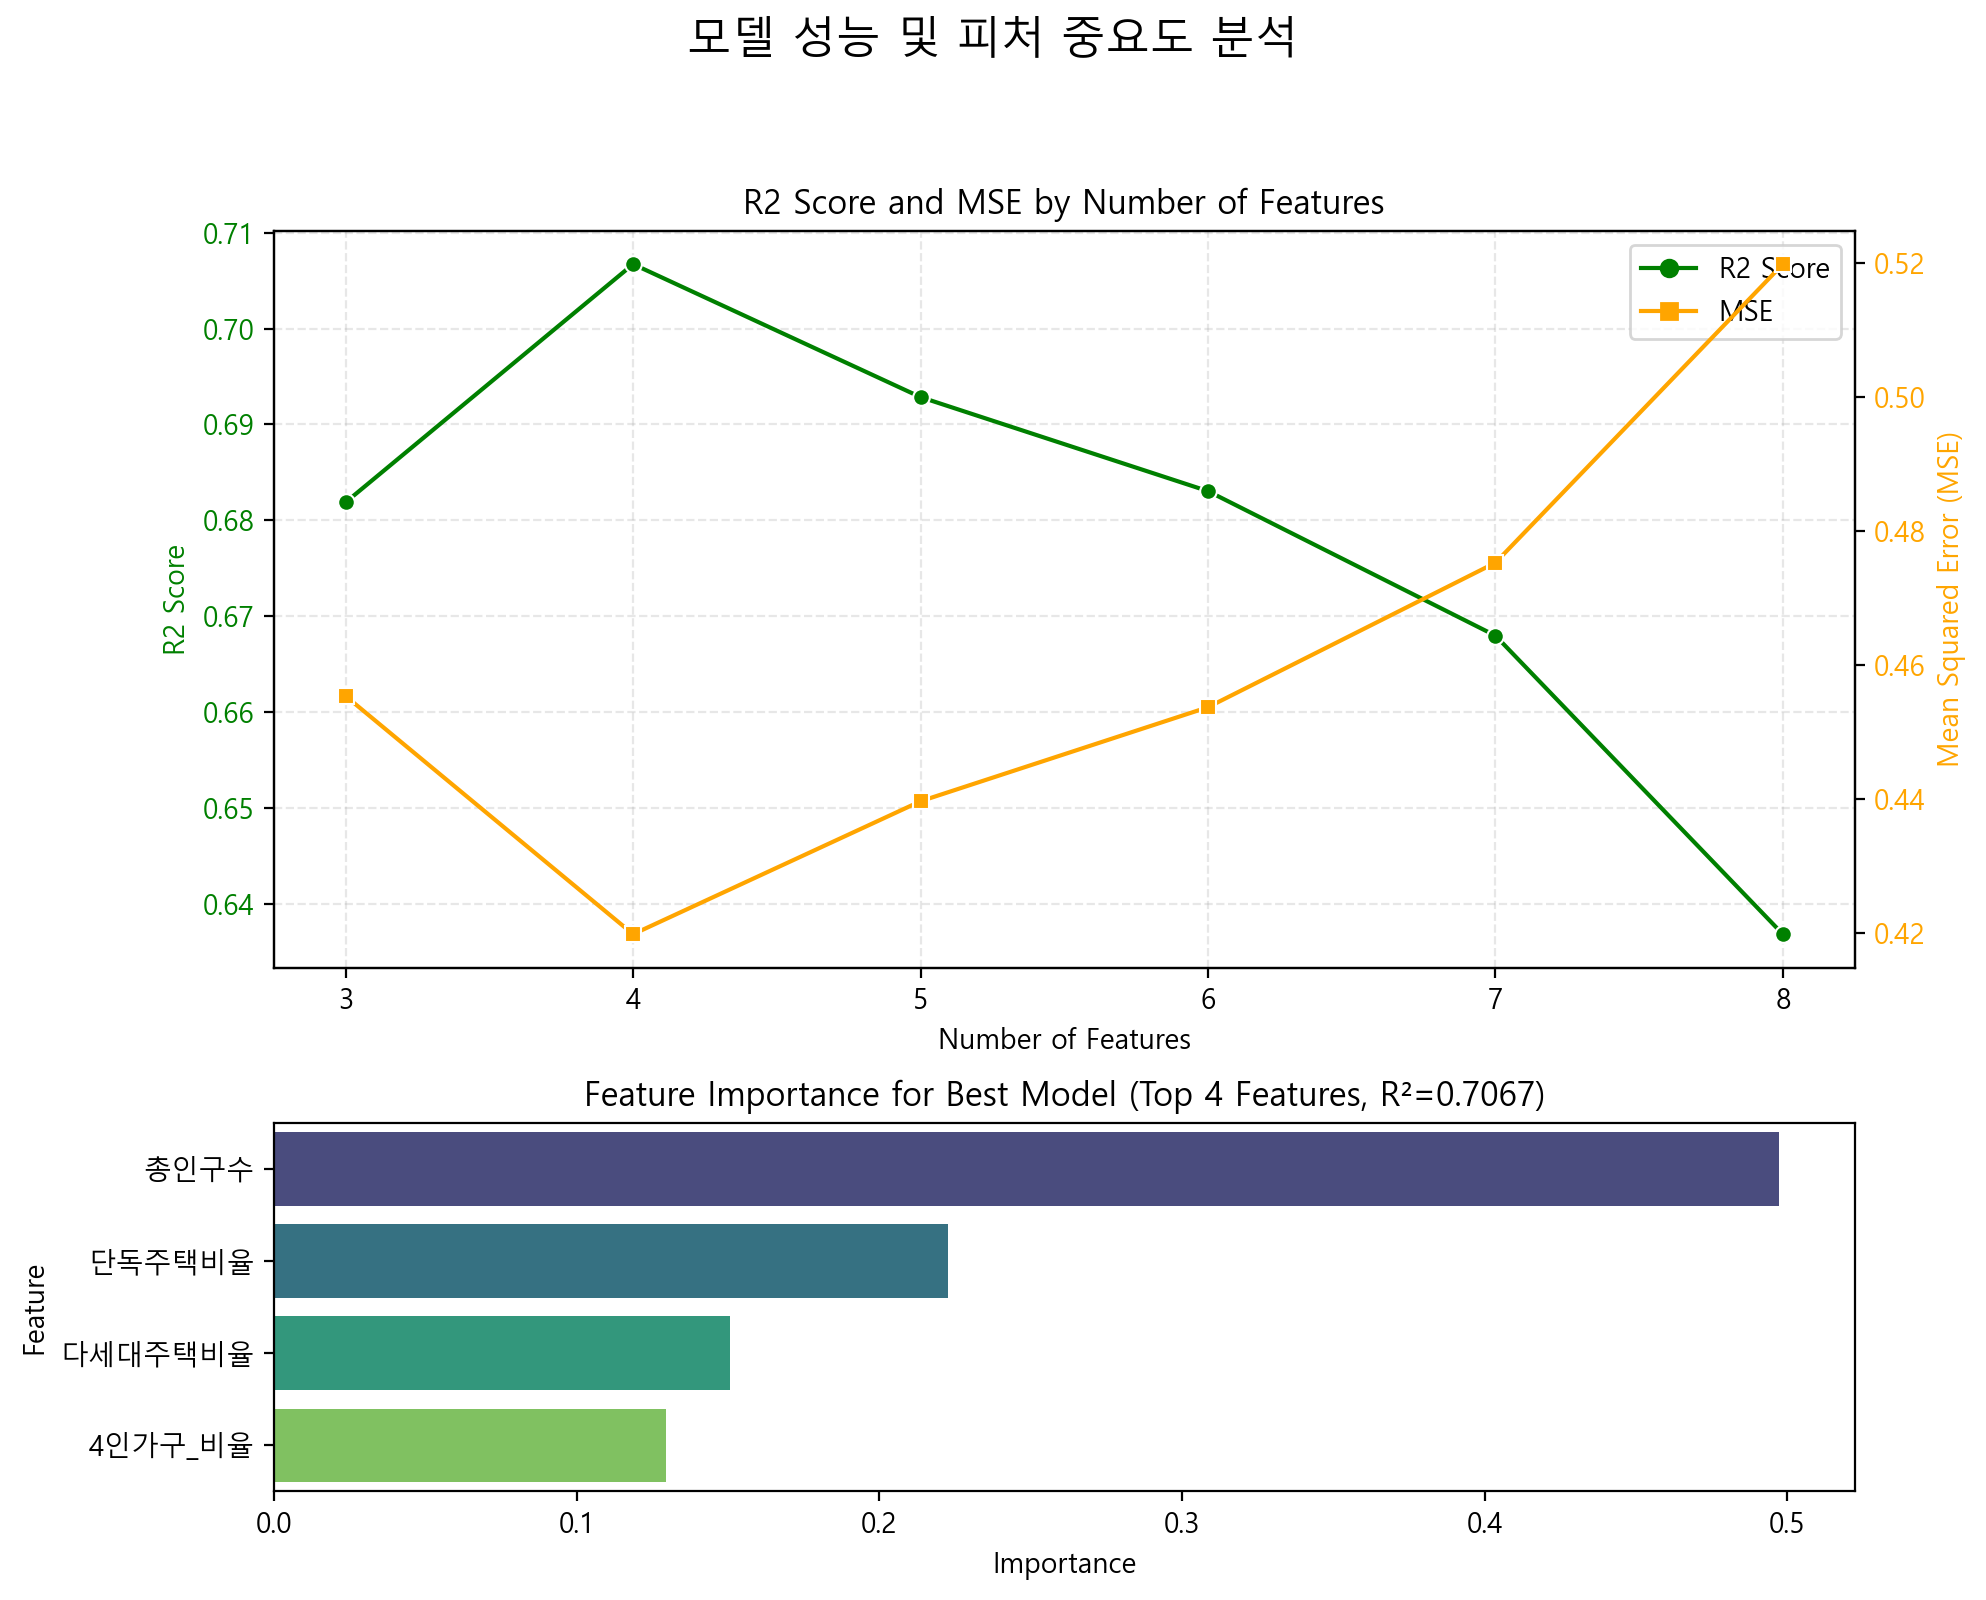

In [180]:
plot_model_performance_and_importance(results_set5)

<br>

### test 7)
- 지금까지 가장 높았던 변수 조합에서 '총인구수'를 '주민등록세대수'로 바꿔서 테스트

In [36]:
my_selected_features_set7 = [
    '주민등록세대수', '단독주택비율', '다세대주택비율', '4인가구_비율'
]

# 함수 호출 및 결과 저장
results_set7 = explore_feature_combinations(
    data=df,
    selected_core_features=my_selected_features_set7,
    min_features=2     # 2개부터 조합 시작
)

print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set7.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 4개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 2개의 feature 조합 탐색 시작 ---]
  > 조합 6/6 완료 - R2: 0.2241, MSE: 1.1107

[--- 3개의 feature 조합 탐색 시작 ---]
  > 조합 4/4 완료 - R2: 0.5853, MSE: 0.5936

[--- 4개의 feature 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.6771, MSE: 0.4623

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
    num_features                    selected_features        R2       MSE  \
0              2                    [주민등록세대수, 단독주택비율]  0.682274  0.454800   
6              3           [주민등록세대수, 단독주택비율, 다세대주택비율]  0.667442  0.476031   
10             4  [주민등록세대수, 단독주택비율, 다세대주택비율, 4인가구_비율]  0.677056  0.462269   

                                  feature_importances  
0              [0.638149275073153, 0.361850724926847]  
6   [0.5410326370197117, 0.24419354869780605, 0.21...  
10  [0.5004955950124688, 0.20252125873605065, 0.16...  

--- R2 기준 상위 3개 피처 조합 ---


,num_features,selected_features,R2,MSE,feature_importances
0,2,"[주민등록세대수, 단독주택비율]",0.682274,0.454800,"[0.638149275073153, 0.361850724926847]"
1,4,"[주민등록세대수, 단독주택비율, 다세대주택비율, 4인가구_비율]",0.677056,0.462269,"[0.5004955950124688, 0.20252125873605065, 0.16..."
2,3,"[주민등록세대수, 단독주택비율, 다세대주택비율]",0.667442,0.476031,"[0.5410326370197117, 0.24419354869780605, 0.21..."


> - `총인구수`가 `주민등록세대수`보다 좋은 결과를 가져옴

<br><br>

---
## 04. 2023년 데이터를 test 데이터로 한 RandomForest 
- `[총인구수, 단독주택비율, 다세대주택비율, 4인가구_비율]` 조합 계속 유지하면서
- **2023년 데이터를 test set** 으로 사용하고, 나머지 모든 데이터를 train set으로 학습
- 예측값과 실제 혼합배출_후_재활용량을 비교

<br>

- 부산만 테스트하지 않는 이유: 전국적으로 일반화된 예측 가능성을 확인하기 위해
- 부산만 했더니 결과가 너무 안 좋음..

In [142]:
# 사용할 피처
selected_features = ['총인구수', '단독주택비율', '다세대주택비율', '4인가구_비율']

# 연도 2023 & 시도 == '부산' >> test 데이터
test_mask = (df['연도_2023'] == 1) & (df['시도'] == '부산')
test = df[test_mask].copy()

# 나머지는 train 데이터
train = df[~test_mask].copy()

In [143]:
# X, y 분리
X_train = train[selected_features]
y_train = train['log_혼합배출_후_재활용량']

X_test = test[selected_features]
y_test = test['log_혼합배출_후_재활용량']

In [144]:
# 모델 정의
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', n_estimators=300,
                      random_state=42)

In [145]:
# 예측
y_pred_log = model.predict(X_test)

# 성능 평가
r2 = r2_score(y_test, y_pred_log)
mse = mean_squared_error(y_test, y_pred_log)

print("2023년 전국 데이터 테스트")
print(f"R²: {r2:.4f}")
print(f"MSE: {mse:,.2f}")

2023년 전국 데이터 테스트
R²: 0.3640
MSE: 1.04


In [146]:
# 예측 vs 실제 비교표
comparison_df = test[['행정구역', '혼합배출_후_재활용량']].copy()
comparison_df['예측값'] = y_pred.round(2)
comparison_df.rename(columns={'혼합배출_후_재활용량': '실제값'}, inplace=True)
comparison_df = comparison_df[['행정구역', '실제값', '예측값']]
comparison_df.reset_index(drop=True, inplace=True)

In [147]:
comparison_df

,행정구역,실제값,예측값
0,강원_고성군,2467.3,1807.54
1,강원_동해시,12215.6,7142.61
2,강원_삼척시,17719.3,6847.08
3,강원_양구군,2009.0,288.43
4,강원_원주시,26401.4,16918.64
...,...,...,...
125,충남_청양군,628.6,96.33
126,충북_음성군,3834.8,2303.07
127,충북_제천시,2797.0,3209.26
128,충북_진천군,3919.1,2408.72


<br><br>

---
## 05. 취약지역 선정하기

<br>

1. 절대량 기준
    - 혼합배출_후_재활용량 자체가 가장 많은 구 → 실제로 이중 처리량이 많은 지역
    - `df['인구당_재활용량'] = df['혼합배출_후_재활용량'] / df['총인구수']` 이걸로 정규화

<br>

2. 예측 오차 기준
    - 모델이 예측한 값보다 실제 재활용량이 훨씬 많으면 → 패턴보다 비정상적으로 재활용이 많이 된 지역
    - `오차 = 실제값 - 예측값`
    - 오차 > 0: 예측보다 실제값이 더 큼 → 예외적으로 많이 재활용됨
    - 오차 < 0: 모델이 과대평가한 지역

<br>

3. 클러스터링 분류
    - PCA나 KMeans로 유사 군집 만들기
    - 군집 평균 대비 이탈값으로 이상치 (지역) 찾기
    - 이탈도가 높으면 유사한 조건 내에서 **유독 2차 재활용량이 많은 취약지역** 탐색 가능

<br>

- 위 지표들을 사용해서 표준화+평균하거나 가중합에서 종합 취약지수 만들기??

<br>

---
### 현재 문제:
- 전체 데이터를 train:test 8:2로 split하면 0.7xx의 R2가 나오지만, 23년 데이터를 test로 분류하면 R2가 절반으로 줄어듦
> 성능을 유지하면서 23년 부산 지역의 `종량제 중 재활용량` 예측하기

<br>

### 생각해본 해결방법
- 23년을 제외한 나머지 데이터로 train-test 8:2 방법으로 학습을 해 모델을 생성함 (train-validation 느낌)
- 최종 테스트셋으로 2023년을 예측
- 예측값과 실제값을 비교하는 방법으로 오차 분석
    - 오차 > 0이라면 예측값이 실제값보다 크다는 거니깐 타 지역 대비 이중처리된 양이 많은 것
    - 오차가 클수록 모델이 설명하지 못한 비정상적인 패턴이 있다 >> **취약지역 후보**

In [9]:
df.columns

Index(['행정구역', '혼합배출_후_재활용량', '시도', '시군구', '주민등록세대수', '총인구수', '단독주택비율',
       '아파트비율', '연립주택비율', '다세대주택비율', '비주거용주택비율', '총전입', '총전출', '순이동',
       'log_혼합배출_후_재활용량', '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율',
       '5인이상가구_비율', '연도_2019', '연도_2020', '연도_2021', '연도_2022', '연도_2023'],
      dtype='object')

In [11]:
# 23년 데이터 만들기
df_test_2023 = df[df['연도_2023'] == 1].copy().reset_index(drop=True)

# 그 외 데이터 (2023년 부산 제외) → 훈련/검증용
df_modeling = df[~(df['연도_2023'] == 1)].copy()

print(f"23년 부산 데이터프레임 shape: {df_test_2023.shape}")
print(f"train-validation용 데이터프레임 shape: {df_modeling.shape}")

23년 부산 데이터프레임 shape: (130, 25)
train-validation용 데이터프레임 shape: (460, 25)


<br>

### 05-1. 2019 - 2022 train-valid로 조합 다시 테스트

In [12]:
my_selected_features_set8 = [
    '총인구수', '아파트비율', '단독주택비율', '다세대주택비율',
    '2인가구_비율', '4인가구_비율', '순이동', '총전입',
]

# 함수 호출 및 결과 저장
results_set8 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set8,
    min_features=3,
    max_features=8
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set8.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 8개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 3개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.3612, MSE: 1.2582

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 70/70 완료 - R2: 0.4255, MSE: 1.1315

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 56/56 완료 - R2: 0.4727, MSE: 1.0385

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 28/28 완료 - R2: 0.5306, MSE: 0.9245

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 8/8 완료 - R2: 0.5345, MSE: 0.9168

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 1/1 완료 - R2: 0.5541, MSE: 0.8782

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                                  selected_features  \
8               3                            [총인구수, 단독주택비율, 4인가구_비율]   
58              4                     [총인구수, 아파트비율, 단독주택비율, 4인가구_비율]   
130             5            [총인구수, 아파트비율, 단독주택비율, 2인가구_비율, 4인가구_비율]   
189             6       [총인구수, 아파트비율, 단독주택비율, 2인가구_비율, 4인가구_비율, 총전입]   
214             7  [총인구수, 아파트비율, 단독주택비율, 2인가구_비율, 4인가구_비율, 순이동, 총전입]   
218             8  [총인구수, 아파트비율, 단독주택비율, 다세대주택비율, 2인가구_비율, 4인가구_비...   

         

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 아파트비율, 단독주택비율, 2인가구_비율, 4인가구_비율]",0.603619,0.780715,"[0.4379664207733502, 0.13693507021947424, 0.20..."
1,4,"[총인구수, 아파트비율, 단독주택비율, 4인가구_비율]",0.589998,0.807544,"[0.48162426102076894, 0.16207158577457526, 0.2..."
2,4,"[총인구수, 단독주택비율, 2인가구_비율, 4인가구_비율]",0.586796,0.813850,"[0.4806855120965504, 0.2411057665951831, 0.164..."


<br>

---
### 2019 - 2022 train-valid로 조합 다시 테스트 2)

In [13]:
my_selected_features_set9 = [
    '총인구수', '단독주택비율', '아파트비율', '연립주택비율', '다세대주택비율',
    '1인가구_비율', '2인가구_비율', '3인가구_비율', '4인가구_비율', '5인이상가구_비율'
]

# 함수 호출 및 결과 저장
results_set9 = explore_feature_combinations(
    data=df_modeling,
    selected_core_features=my_selected_features_set9,
    min_features=4,
    max_features=8
)
print("\n--- R2 기준 상위 3개 피처 조합 ---")
results_set9.head(3) # 가장 성능이 좋은 상위 3개 조합 출력

--- 10개의 피처 내 조합 Random Forest 성능 탐색 시작 ---

[--- 4개 피처 조합 탐색 시작 ---]
  > 조합 100/210 완료 - R2: 0.4758, MSE: 1.0326
  > 조합 200/210 완료 - R2: 0.3076, MSE: 1.3637
  > 조합 210/210 완료 - R2: 0.3374, MSE: 1.3050

[--- 5개 피처 조합 탐색 시작 ---]
  > 조합 100/252 완료 - R2: 0.5501, MSE: 0.8862
  > 조합 200/252 완료 - R2: 0.3762, MSE: 1.2286
  > 조합 252/252 완료 - R2: 0.3369, MSE: 1.3061

[--- 6개 피처 조합 탐색 시작 ---]
  > 조합 100/210 완료 - R2: 0.5449, MSE: 0.8963
  > 조합 200/210 완료 - R2: 0.3856, MSE: 1.2102
  > 조합 210/210 완료 - R2: 0.3912, MSE: 1.1991

[--- 7개 피처 조합 탐색 시작 ---]
  > 조합 100/120 완료 - R2: 0.4550, MSE: 1.0734
  > 조합 120/120 완료 - R2: 0.4424, MSE: 1.0982

[--- 8개 피처 조합 탐색 시작 ---]
  > 조합 45/45 완료 - R2: 0.4371, MSE: 1.1088

--- 탐색 완료 ---

--- 각 피처 개수별 최고 R2 ---
     num_features                                  selected_features  \
11              4                    [총인구수, 단독주택비율, 연립주택비율, 4인가구_비율]   
241             5           [총인구수, 단독주택비율, 연립주택비율, 2인가구_비율, 4인가구_비율]   
513             6  [총인구수, 단독주택비율, 연립주택비율, 2인가

,num_features,selected_features,R2,MSE,feature_importances
0,5,"[총인구수, 단독주택비율, 연립주택비율, 2인가구_비율, 4인가구_비율]",0.632507,0.723818,"[0.4426227709799912, 0.20982029764790425, 0.12..."
1,6,"[총인구수, 단독주택비율, 연립주택비율, 2인가구_비율, 3인가구_비율, 4인가구_비율]",0.627170,0.734329,"[0.42835037730522746, 0.19837453053913756, 0.1..."
2,6,"[총인구수, 단독주택비율, 아파트비율, 연립주택비율, 2인가구_비율, 4인가구_비율]",0.626693,0.735268,"[0.4121619015642493, 0.18675137483948367, 0.10..."


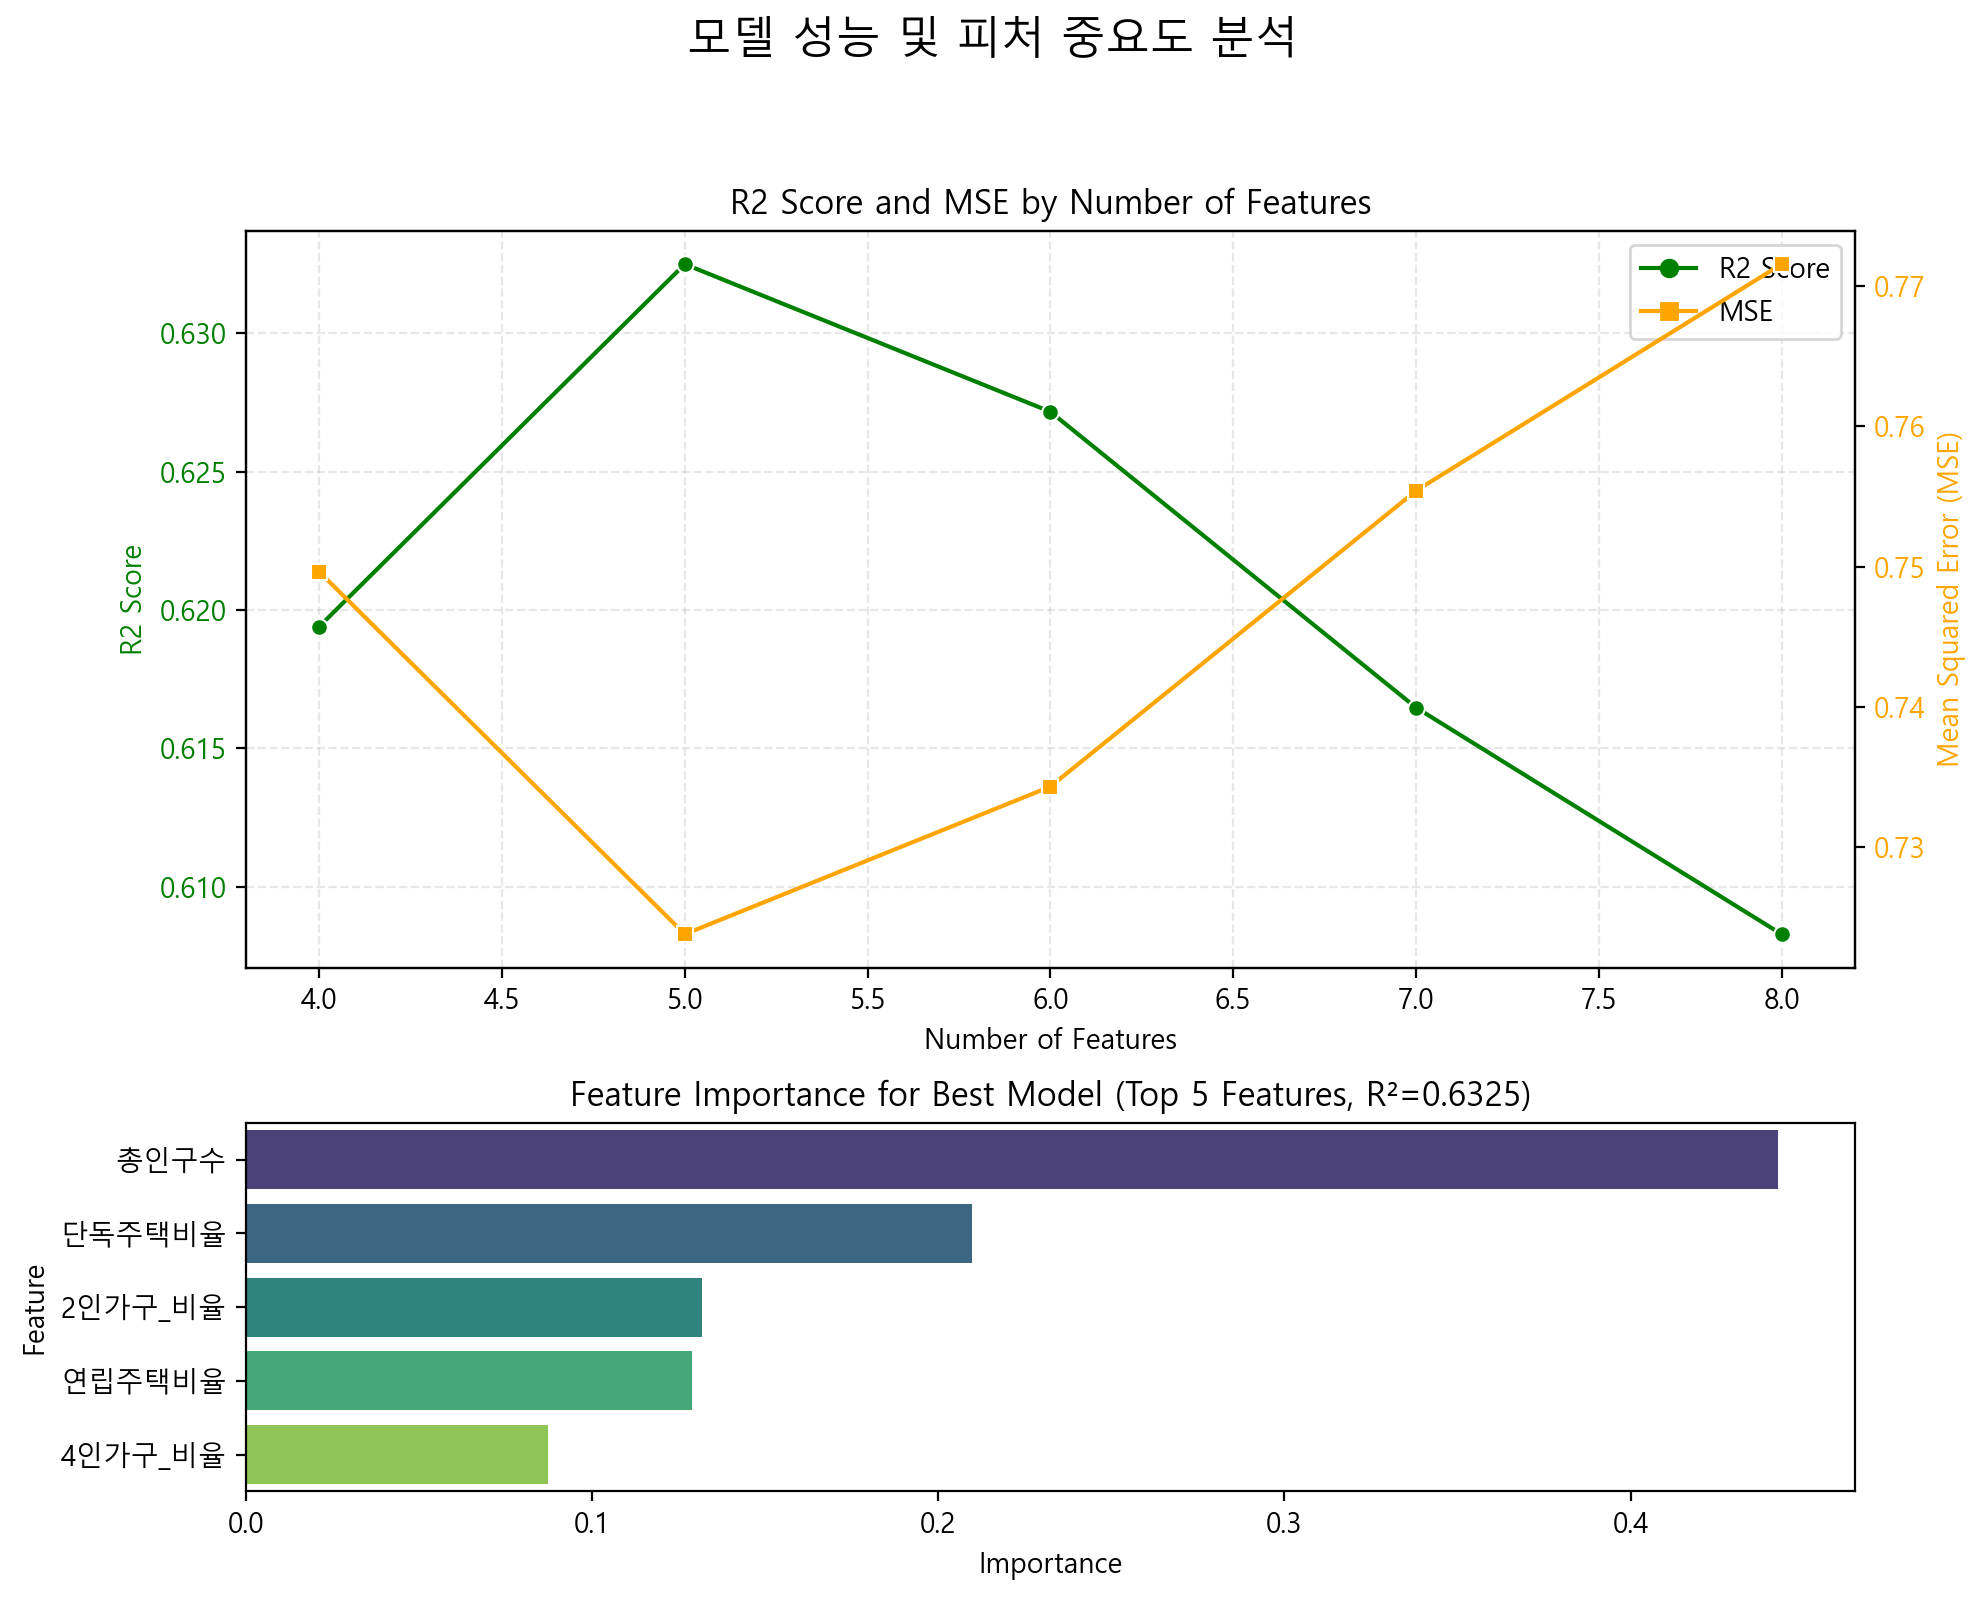

In [14]:
plot_model_performance_and_importance(results_set9)

<br>

---
### 05-2. RandomForest 모델 튜닝
- `[총인구수, 단독주택비율, 연립주택비율, 2인가구_비율, 4인가구_비율]` 조합으로 하이퍼파라미터 튜닝
- 튜닝 없을 때: `0.632507`

In [16]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import randint

In [17]:
selected_features = ['총인구수', '단독주택비율', '연립주택비율', '2인가구_비율', '4인가구_비율']
X = df_modeling[selected_features]
y = df_modeling['log_혼합배출_후_재활용량']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [250, 275],
    'max_depth': [12, 13],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1],
    'max_features': ['sqrt', 'log2', 0.6]
}

In [34]:
# 모델 정의 및 그리드서치
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
# 모델 훈련
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [12, 13],
                         'max_features': ['sqrt', 'log2', 0.6],
                         'min_samples_leaf': [1], 'min_samples_split': [2, 3],
                         'n_estimators': [250, 275]},
             scoring='r2', verbose=1)

In [35]:
# 테스트 예측
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

# 성능 출력
print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"테스트 세트 R²: {r2_score(y_val, y_pred):.4f}")
print(f"테스트 세트 MSE: {mean_squared_error(y_val, y_pred):.4f}")


최적 파라미터: {'max_depth': 13, 'max_features': 0.6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
테스트 세트 R²: 0.6225
테스트 세트 MSE: 0.7435


In [ ]:
# history
"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [250, 275, 300],
    'max_depth': [12, 13, 14, 15, 16],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1],
}
최적 파라미터: {'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}
테스트 세트 R²: 0.6283
테스트 세트 MSE: 0.7321
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [50, 100, 125],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2, 4],
}
최적 파라미터: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 125}
테스트 세트 R²: 0.5982
테스트 세트 MSE: 0.7914
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [200, 225, 250],
    'max_depth': [10, 13, 15],
    'min_samples_split': [3, 4],
    'min_samples_leaf': [1, 2, 4],
}
최적 파라미터: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 250}
테스트 세트 R²: 0.6265
테스트 세트 MSE: 0.7357
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [5, 10, 12],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2, 4],
}
최적 파라미터: {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
테스트 세트 R²: 0.6323
테스트 세트 MSE: 0.7241
"""

"""
# 하이퍼파라미터 후보 설정
param_grid = {
    'n_estimators': [125, 150, 175, 200],
    'max_depth': [10, 11, 12, 13],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
}
최적 파라미터: {'max_depth': 11, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 175}
테스트 세트 R²: 0.6073
테스트 세트 MSE: 0.7735
"""

> 여러가지 하이퍼파라미터 조합으로 테스트한 결과 기본 설정에 가까운 값이 **튜닝 결과가 가장 좋음**  
튜닝 없이 가겠다..!

<br>

---
### 05-3. 23년 test 및 오차값 확인

In [36]:
# X, y 분리 (훈련용 데이터)
X = df_modeling[selected_features]
y = df_modeling['log_혼합배출_후_재활용량']

# 훈련-검증 8:2 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
# GridSearch를 통해 찾은 가장 높은 성능을 보이는 모델 정의
model = RandomForestRegressor(
    n_estimators=250,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=250, random_state=42)

In [38]:
# 검증 성능 확인
y_val_pred = model.predict(X_val)
r2_val = r2_score(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)

print("[검증 성능]")
print(f"R² (Validation): {r2_val:.4f}")
print(f"MSE (Validation): {mse_val:.4f}")

[검증 성능]
R² (Validation): 0.6325
MSE (Validation): 0.7238


In [39]:
# 23년 전국 대상 예측
X_test_2023 = df_test_2023[selected_features]
y_test_2023 = df_test_2023['log_혼합배출_후_재활용량']

In [40]:
# 예측 수행
y_pred_2023 = model.predict(X_test_2023)

df_test_2023['예측_log'] = y_pred_2023
df_test_2023['실제_log'] = y_test_2023
df_test_2023['예측값'] = np.expm1(df_test_2023['예측_log'])
df_test_2023['실제값'] = np.expm1(df_test_2023['실제_log'])
df_test_2023['오차(실제값기준)'] = df_test_2023['실제값'] - df_test_2023['예측값']

print("[2023년 테스트 성능 평가]")

# 전국 2023년 성능 (로그 기준)
r2_2023 = r2_score(y_test_2023, y_pred_2023)
mse_2023 = mean_squared_error(y_test_2023, y_pred_2023)
print(f"2023년 로그 기준 R2: {r2_2023:.4f}")
print(f"2023년 로그 기준 MSE: {mse_2023:.4f}")

# 실제 스케일 기준 R2
r2_2023_real = r2_score(df_test_2023['실제값'], df_test_2023['예측값'])
mse_2023_real = mean_squared_error(df_test_2023['실제값'], df_test_2023['예측값'])
print(f"\n2023년 실제값 기준 R2: {r2_2023_real:.4f}")
print(f"2023년 실제값 기준 MSE: {mse_2023_real:.4f}")

[2023년 테스트 성능 평가]
2023년 로그 기준 R2: 0.3589
2023년 로그 기준 MSE: 1.0475

2023년 실제값 기준 R2: 0.3002
2023년 실제값 기준 MSE: 175246016.8329


In [42]:
# 부산 지역만 확인!
df_busan_2023 = df_test_2023[df_test_2023['시도'] == '부산'].copy().reset_index(drop=True)

# 부산 성능 (로그 기준)
r2_busan_2023 = r2_score(df_busan_2023['실제_log'], df_busan_2023['예측_log'])
mse_busan_2023 = mean_squared_error(df_busan_2023['실제_log'], df_busan_2023['예측_log'])

# 부산 성능 (실제)
r2_busan_2023_real = r2_score(df_busan_2023['실제값'], df_busan_2023['예측값'])
mse_busan_2023_real = mean_squared_error(df_busan_2023['실제값'], df_busan_2023['예측값'])

print("[2023년 부산 지역 테스트 성능 평가]")
print(f"23년 부산 로그 기준 R2: {r2_busan_2023:.4f}")
print(f"23년 부산 기준 MSE: {mse_busan_2023:.4f}")
print(f"\n23년 부산 실제값 기준 R2: {r2_busan_2023_real:.4f}")
print(f"23년 부산 실제값 기준 MSE: {mse_busan_2023_real:.4f}")

[2023년 부산 지역 테스트 성능 평가]
23년 부산 로그 기준 R2: -1.8398
23년 부산 기준 MSE: 0.5426

23년 부산 실제값 기준 R2: -0.3879
23년 부산 실제값 기준 MSE: 92882371.6528


In [43]:
print("\n[2023년 부산 예측 오차 상위 5개]")
df_busan_2023[['시군구', '예측값', '실제값', '오차(실제값기준)']].sort_values(by='오차(실제값기준)', ascending=False).head(5)


[2023년 부산 예측 오차 상위 5개]


,시군구,예측값,실제값,오차(실제값기준)
6,부산진구,16583.525447,41448.2,24864.674553
1,금정구,8376.629922,24013.1,15636.470078
9,사하구,12701.371490,24589.7,11888.328510
3,남구,13138.163087,23032.7,9894.536913
11,수영구,7031.321000,15895.6,8864.279000


<br>

---
### 05-4. 예측 오차 시각화
> "실제값이 예측보다 훨씬 높다" >> 예상보다 많은 양이 이중처리/재활용되었고 >> 예측이 어려운 과부하 상황이므로 정책상 취약 구역 후보

<br>

### 1) 순위 확인

In [50]:
# 부산 구별 예측 정확도 순위 (예측 오차가 작은 순서대로 — 절댓값 기준)
df_busan_2023['오차절댓값'] = df_busan_2023['오차(실제값기준)'].abs()
accuracy_ranking = df_busan_2023.sort_values(by='오차절댓값').reset_index(drop=True)

print("\n[시군구별 예측 정확도 순위 — 오차 절댓값 기준]")
accuracy_ranking[['시군구', '예측값', '실제값', '오차(실제값기준)', '오차절댓값']]


[시군구별 예측 정확도 순위 — 오차 절댓값 기준]


,시군구,예측값,실제값,오차(실제값기준),오차절댓값
0,해운대구,11393.108144,11254.5,-138.608144,138.608144
1,동래구,15386.512292,14674.0,-712.512292,712.512292
2,강서구,10480.078333,11805.7,1325.621667,1325.621667
3,사상구,8972.379945,11497.8,2525.420055,2525.420055
4,서구,1257.558178,6157.8,4900.241822,4900.241822
5,동구,5128.870073,10200.1,5071.229927,5071.229927
6,기장군,7803.452534,13154.8,5351.347466,5351.347466
7,중구,7253.271724,13367.1,6113.828276,6113.828276
8,영도구,4221.659244,11404.7,7183.040756,7183.040756
9,북구,12282.043383,19735.6,7453.556617,7453.556617


<br>

### 2) lineplot

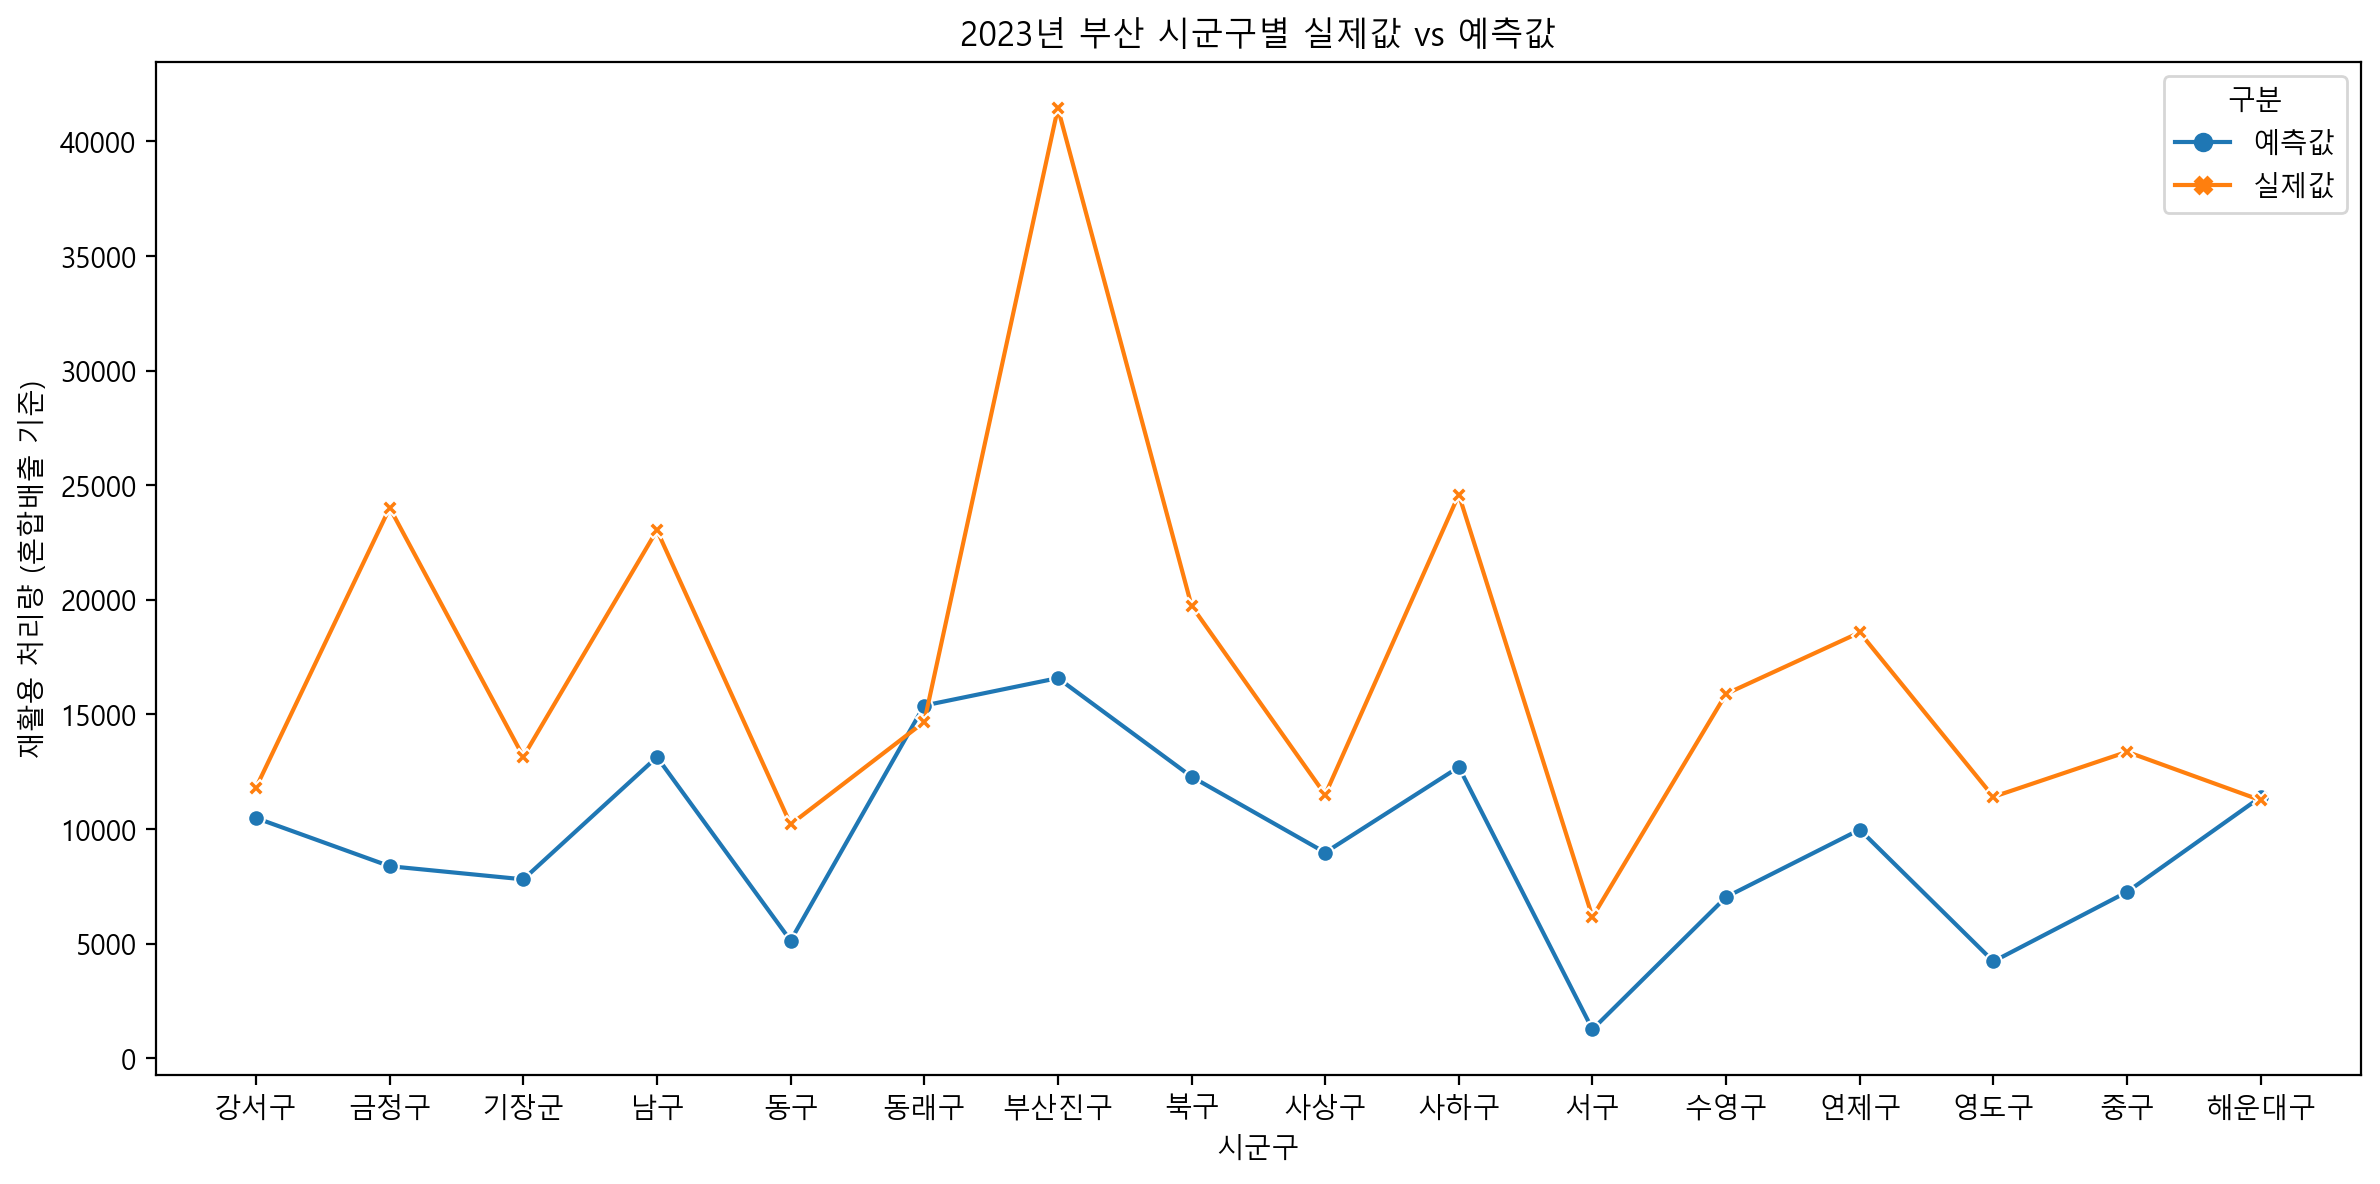

In [55]:
# 시군구별 예측값/실제값 형태 변환
df_plot = df_busan_2023[['시군구', '예측값', '실제값']].melt(id_vars='시군구', var_name='구분', value_name='값')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='시군구', y='값', hue='구분', style='구분', markers=True, dashes=False, sort=False)
plt.title('2023년 부산 시군구별 실제값 vs 예측값')
plt.ylabel('재활용 처리량 (혼합배출 기준)')
plt.xlabel('시군구')
plt.tight_layout()
plt.legend(title='구분')

### 2) barplot

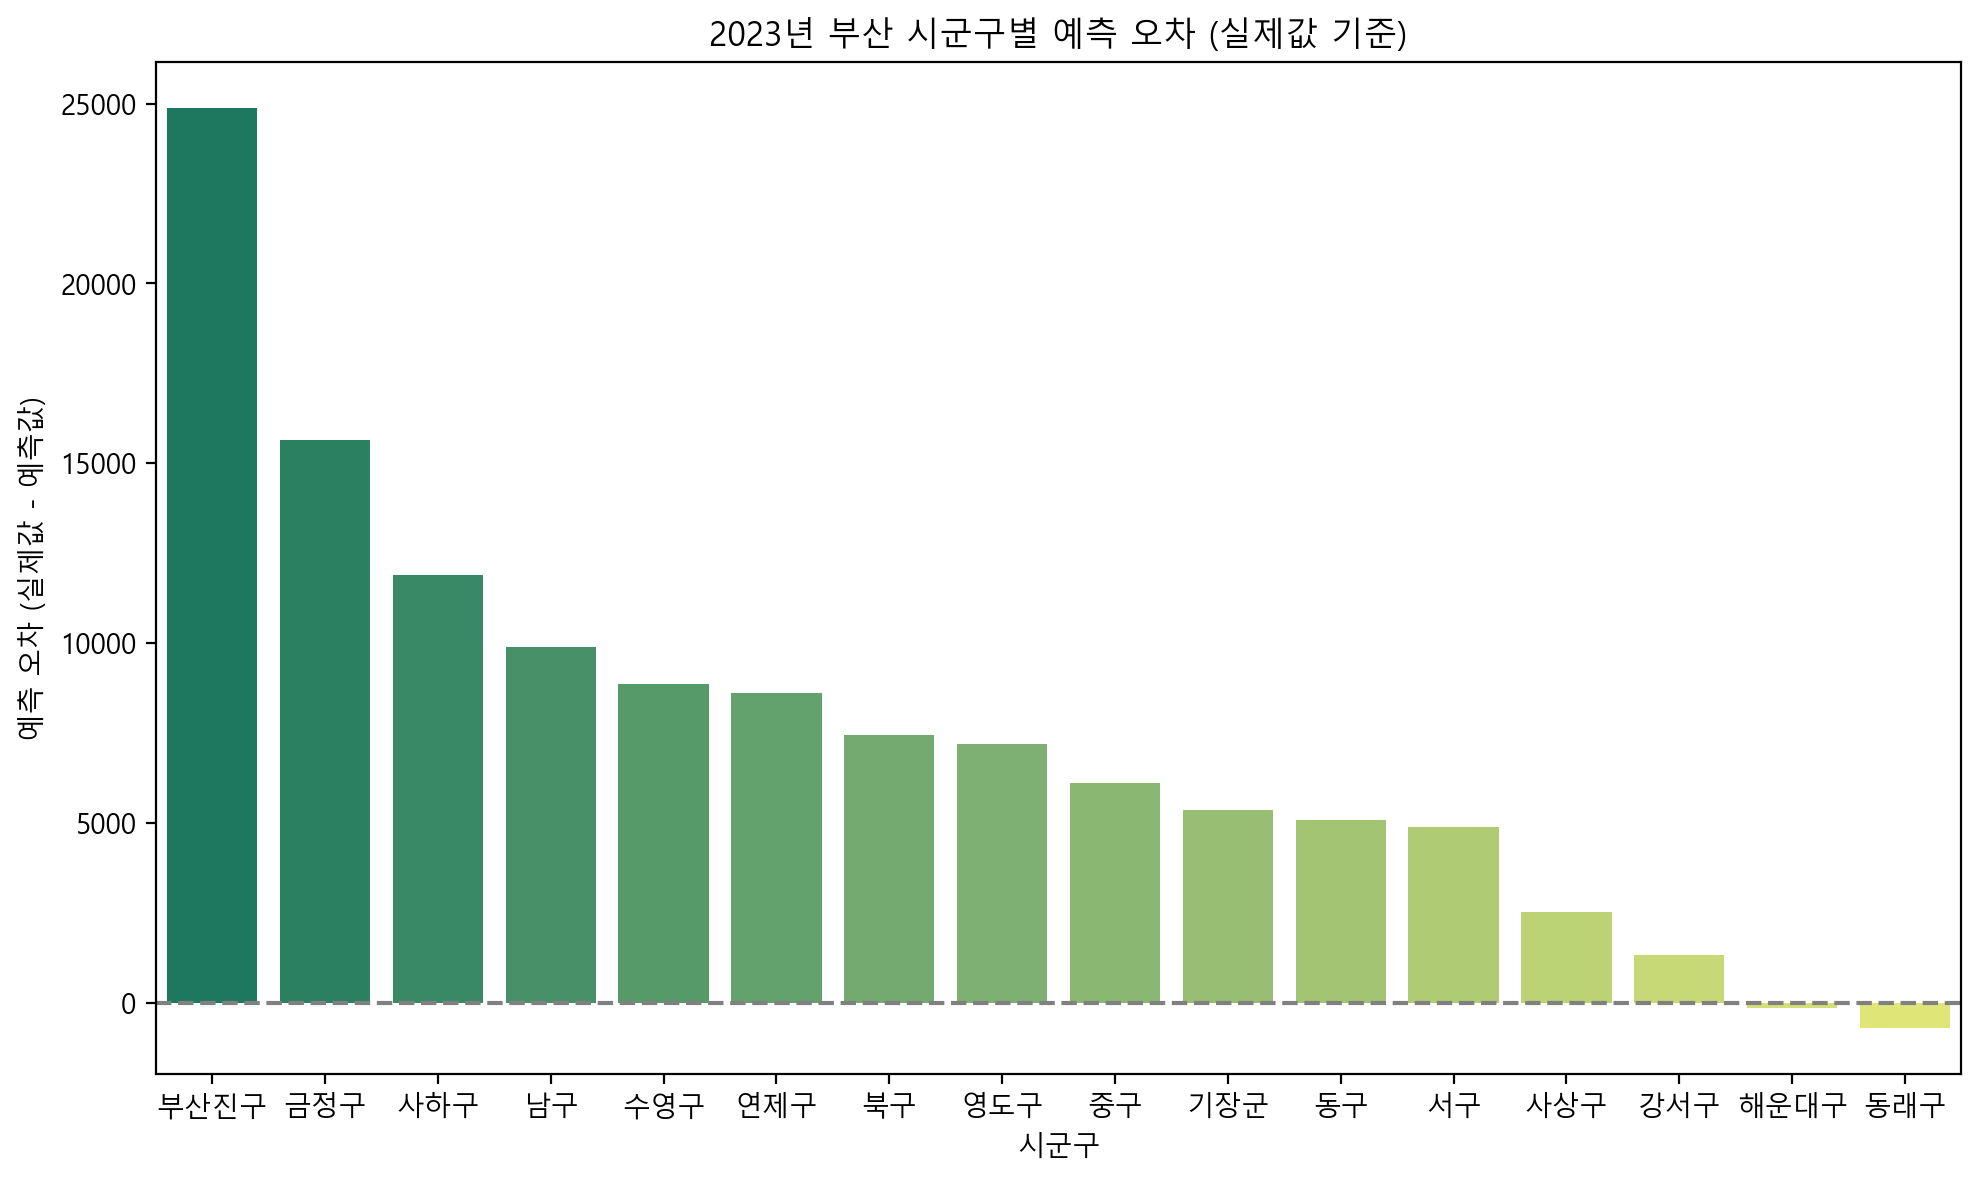

In [53]:
plt.figure(figsize=(10, 6))
df_sorted_heatmap = df_busan_2023.sort_values(by='오차(실제값기준)', ascending=False)
sns.barplot(data=df_sorted_heatmap, x='시군구', y='오차(실제값기준)', palette='summer')
plt.title('2023년 부산 시군구별 예측 오차 (실제값 기준)')
plt.ylabel('예측 오차 (실제값 - 예측값)')
plt.xlabel('시군구')
plt.axhline(0, color='gray', linestyle='--')
plt.tight_layout()